**LAB EXPERIMENT 07\
Clustering using K-Means and Gaussian Mixture Models (GMM)**\
NAME: Priya Dharshini R\
ROLL NO.: 24BAD092

**SCENARIO 1 – CLUSTERING USING K-MEANS**

**Problem Statement**\
Group customers/data points into clusters based on similarity using K-Means clustering.

**Dataset** (Kaggle – Public)\
**Mall Customer Segmentation Dataset**\
Dataset Link: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in￾python

**Target Variable:**\
Cluster labels (no predefined labels – unsupervised learning)

**Input Feature:**\
• Annual Income\
• Spending Score\
• Age (optional)

**IN-LAB TASKS**
1. Import required Python libraries (NumPy, Pandas, Matplotlib, Scikit-learn)
2. Load the dataset
3. Perform data preprocessing (handling missing values, scaling)
4. Select relevant features
5. Use Elbow Method to determine optimal K
6. Apply K-Means clustering
7. Assign cluster labels
8. Visualize clusters
9. Interpret cluster characteristics

**Evaluation Metrics**\
• Inertia (Within-cluster sum of squares)\
• Silhouette Score

**Analysis Tasks**\
• Observe how different K values affect clustering\
• Analyze compactness and separation of clusters\
• Identify customer segments (e.g., high income–high spending)\
• Study sensitivity to initialization

**Visualization**\
• Elbow curve (K vs inertia)\
• Scatter plot of clusters\
• Cluster centroids

Name: Priya Dharshini
Roll No: 24BAD092
Dataset Snapshot:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40 



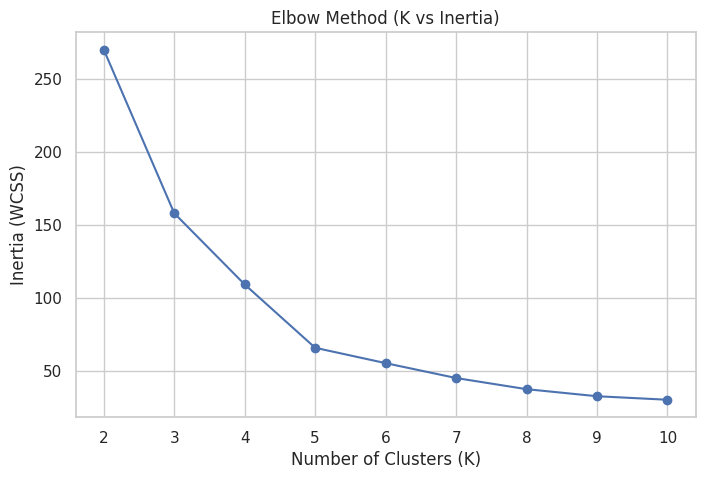

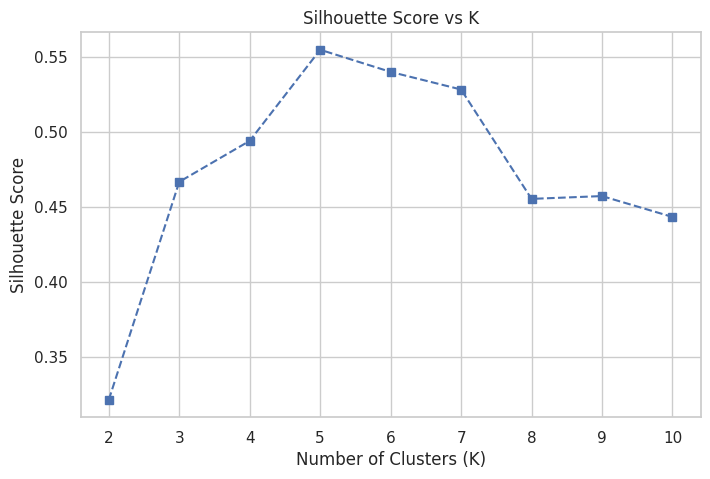

Optimal K chosen: 5
Final Inertia (WCSS): 65.57
Final Silhouette Score: 0.5547



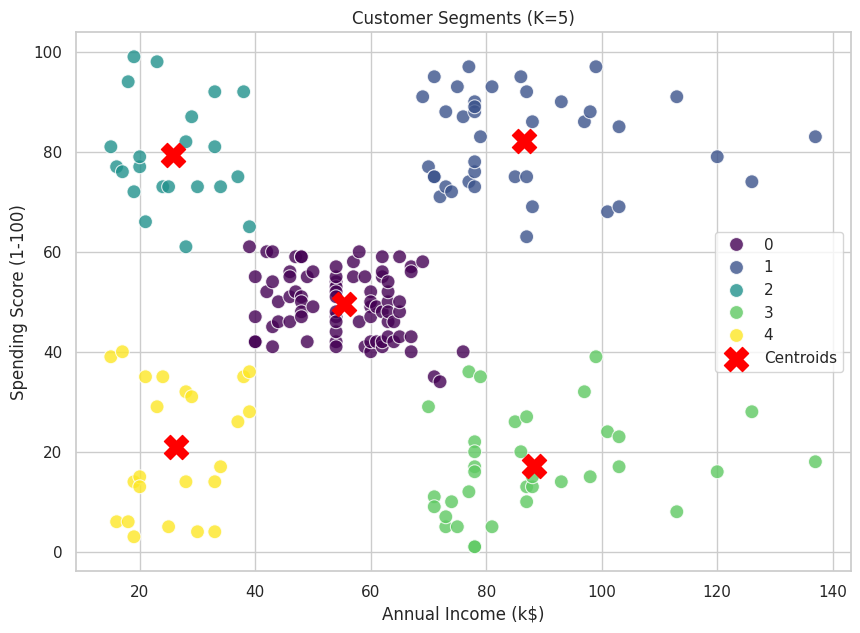

In [3]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings

print("Name: Priya Dharshini")
print("Roll No: 24BAD092")

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv(r"/content/sample_data/Mall_Customers.csv")

print("Dataset Snapshot:")
print(df.head(), "\n")

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute Inertia and Silhouette
inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# VISUAL 1: Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method (K vs Inertia)')
plt.show()

# VISUAL 2: Silhouette Score
plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, marker='s', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')
plt.show()

# Apply KMeans
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

cluster_labels = kmeans_final.fit_predict(X_scaled)
df['Cluster'] = cluster_labels

final_inertia = kmeans_final.inertia_
final_silhouette = silhouette_score(X_scaled, cluster_labels)

print(f"Optimal K chosen: {optimal_k}")
print(f"Final Inertia (WCSS): {final_inertia:.2f}")
print(f"Final Silhouette Score: {final_silhouette:.4f}\n")

# VISUAL 3: Cluster Scatter + Centroids
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis',
    s=100,
    alpha=0.8
)

centroids_original_scale = scaler.inverse_transform(kmeans_final.cluster_centers_)

plt.scatter(
    centroids_original_scale[:, 0],
    centroids_original_scale[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segments (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()



**SCENARIO 2 – CLUSTERING USING GMM**

**Problem Statement**\
Cluster data using Gaussian Mixture Models to capture probabilistic cluster membership.

**Dataset**\
 (Same / Alternative Dataset)\
Same dataset (or any numerical dataset)

**Target Variable:**\
Cluster probabilities and labels

**Input Features**\
• Annual Income\
• Spending Score\
• Age (optional)

**IN-LAB TASKS**
1. Load dataset
2. Perform preprocessing and scaling
3. Apply Gaussian Mixture Model (GMM)
4. Choose number of components (clusters)
5. Fit model using Expectation-Maximization (EM)
6. Predict cluster probabilities
7. Assign clusters based on highest probability
8. Compare with K-Means clustering

**Evaluation Metrics**\
• Log-Likelihood\
• AIC (Akaike Information Criterion)\
• BIC (Bayesian Information Criterion)\
• Silhouette Score

**Analysis Tasks**\
• Compare soft vs hard clustering\
• Analyze overlapping clusters\
• Observe cluster shapes (elliptical vs spherical)\
• Compare flexibility with K-Means

**Visualization**\
• Cluster probability distribution\
• GMM contour plots\
• Comparison plot (K-Means vs GMM)

Priyadharshini R
24BAD092
Exp 7

GMM Evaluation Metrics:
Log-Likelihood: -3.419766641713204
AIC: 1465.9066566852816
BIC: 1627.5242076461354
Silhouette Score (GMM): 0.37644074990819204


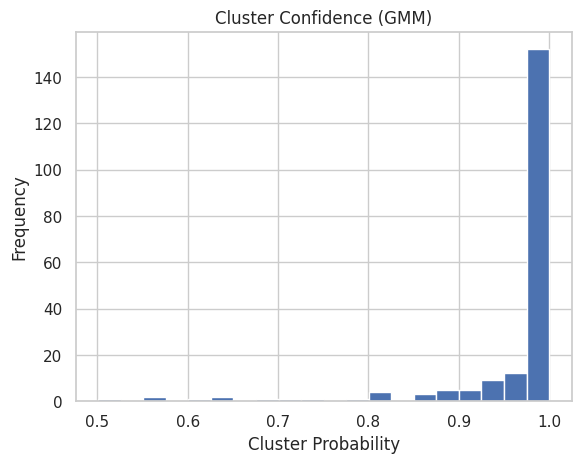

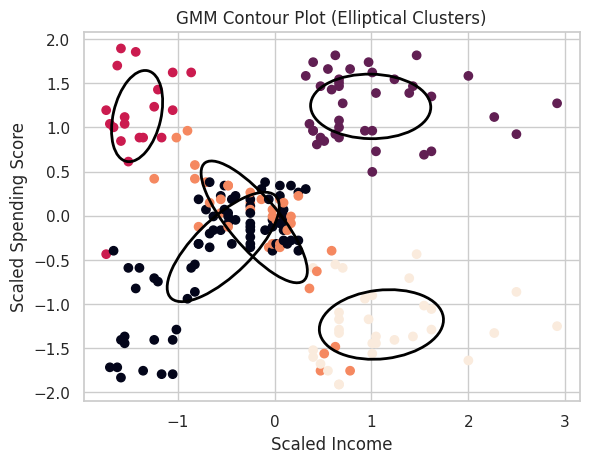


K-Means Evaluation:
Silhouette Score (K-Means): 0.40846873777345605


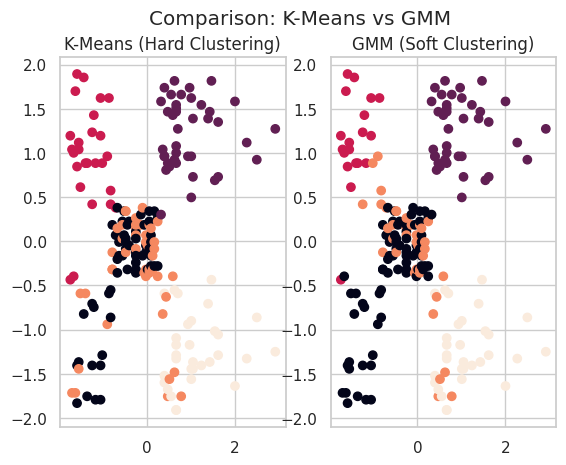

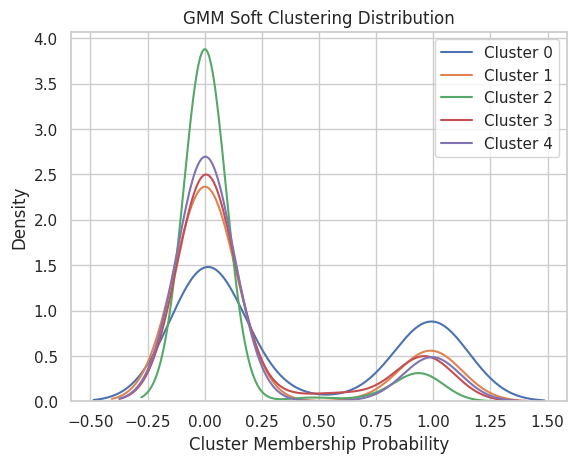

In [4]:
# SCENARIO 2 – GMM CLUSTERING
print("Priyadharshini R\n24BAD092\nExp 7")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib.patches import Ellipse

# Load dataset
df = pd.read_csv(r"/content/sample_data/Mall_Customers.csv")

# Features
X = df[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']]

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# GMM MODEL
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

labels_gmm = gmm.predict(X_scaled)
prob = gmm.predict_proba(X_scaled)

# Evaluation Metrics
print("\nGMM Evaluation Metrics:")
print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score (GMM):", silhouette_score(X_scaled, labels_gmm))


# Probability Histogram
plt.figure()
plt.hist(prob.max(axis=1), bins=20)
plt.xlabel("Cluster Probability")
plt.ylabel("Frequency")
plt.title("Cluster Confidence (GMM)")
plt.show()


# GMM Scatter + Ellipse
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_gmm)

for mean, cov in zip(gmm.means_, gmm.covariances_):
    v, w = np.linalg.eigh(cov[:2, :2])   # only first 2 dims for plotting
    v = 2 * np.sqrt(v)
    u = w[0] / np.linalg.norm(w[0])
    angle = np.degrees(np.arctan2(u[1], u[0]))

    ell = Ellipse(mean[:2], v[0], v[1],
                  angle=angle,
                  edgecolor='black',
                  facecolor='none',
                  linewidth=2)
    plt.gca().add_patch(ell)

plt.title("GMM Contour Plot (Elliptical Clusters)")
plt.xlabel("Scaled Income")
plt.ylabel("Scaled Spending Score")
plt.show()

# K-MEANS MODEL
kmeans = KMeans(n_clusters=5, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)

print("\nK-Means Evaluation:")
print("Silhouette Score (K-Means):", silhouette_score(X_scaled, labels_km))

# Comparison Plot
plt.figure()

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_km)
plt.title("K-Means (Hard Clustering)")

plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_gmm)
plt.title("GMM (Soft Clustering)")

plt.suptitle("Comparison: K-Means vs GMM")
plt.show()

# Probability Density Plot
plt.figure()

for i in range(prob.shape[1]):
    sns.kdeplot(prob[:, i], label="Cluster " + str(i))

plt.xlabel("Cluster Membership Probability")
plt.ylabel("Density")
plt.title("GMM Soft Clustering Distribution")
plt.legend()
plt.show()